In [2]:
import pandas as pd
final_data = pd.read_csv(
    'final_data_for_backtest.csv'
)

final_data['date'] = pd.to_datetime(
    final_data['date']
)

print(final_data.columns.tolist())
final_data.head()
final_data = pd.read_csv(
    'final_data_for_backtest.csv'
)

final_data['date'] = pd.to_datetime(
    final_data['date'],
    errors='coerce'
)

final_data = (
    final_data
    .dropna(subset=['date'])
    .set_index('date')
    .sort_index()
)
final_data['basis'] = final_data['basis']

['date', '交割月份', 'IM_settle', 'MO_synthetic', 'basis', 'rolling_mean', 'upper', 'lower']


In [3]:
# ============================================================
# Global Parameters
# ============================================================

INITIAL_CAPITAL = 10_000_000

IM_MULTIPLIER = 200
MO_MULTIPLIER = 100
groups = 1

ROLLING_WINDOW = 100
MIN_PERIODS = 40
ENTRY_Z = 1.0

MAX_HOLDING_DAYS = 20
NEAR_EXPIRY_DAYS = 2

basis = MO合成期货价格 - IM期货价格

basis低于lower：
买MO合成期货、卖IM，等待basis上升到滚动均值后平仓。

basis高于upper：
卖MO合成期货、买IM，等待basis下降到滚动均值后平仓。

若尚未回归均值，但发生到期、换月或回测结束，则强制平仓。

In [4]:
#平仓逻辑为均值回归
import pandas as pd
import numpy as np

# ==================================================
# 1. 参数
# ==================================================

IM_multiplier = 200
MO_multiplier = 100

# 到期前多少天禁止开仓
no_entry_days = 5

# 是否在合约月份改变时强制平仓
force_exit_on_contract_change = True


# ==================================================
# 2. 数据整理
# ==================================================

bt = final_data.copy()

bt.index = pd.to_datetime(bt.index)
bt = bt.sort_index()

# 确保交割月份类型统一，防止 202401 和 "202401" 比较异常
bt['交割月份'] = bt['交割月份'].astype(str)

# 信号重新定义
# basis = IM - MO
bt['signal'] = 0

# basis过低：做多basis
# 买IM，卖MO
bt.loc[
    bt['basis'] < bt['lower'],
    'signal'
] = 1

# basis过高：做空basis
# 卖IM，买MO
bt.loc[
    bt['basis'] > bt['upper'],
    'signal'
] = -1


# ==================================================
# 3. 如果还没有expiry列，则根据交割月份生成
# ==================================================

if 'expiry' not in bt.columns:

    def third_friday(contract_month):

        contract_month = str(contract_month)

        year = int(contract_month[:4])
        month = int(contract_month[4:6])

        month_dates = pd.date_range(
            start=pd.Timestamp(year=year, month=month, day=1),
            end=pd.Timestamp(year=year, month=month, day=1)
                + pd.offsets.MonthEnd(0),
            freq='D'
        )

        fridays = month_dates[
            month_dates.weekday == 4
        ]

        return fridays[2]

    bt['expiry'] = (
        bt['交割月份']
        .apply(third_friday)
    )

else:
    bt['expiry'] = pd.to_datetime(bt['expiry'])


# ==================================================
# 4. 平仓函数
# ==================================================

def close_position(position, date, row, exit_reason):

    exit_IM = row['IM_settle']
    exit_MO = row['MO_synthetic']
    exit_basis = row['basis']

    # long basis：
    # 买IM，卖MO
    if position['direction'] == 'long_basis':

        profit_IM = (
            position['entry_IM'] - exit_IM
        ) * IM_multiplier * groups

        profit_MO = (
            exit_MO - position['entry_MO']
        ) * MO_multiplier * 2 * groups

    # short basis：
    # 卖IM，买MO
    elif position['direction'] == 'short_basis':

        profit_IM = (
            exit_IM - position['entry_IM']
        ) * IM_multiplier * groups

        profit_MO = (
            position['entry_MO'] - exit_MO
        ) * MO_multiplier * 2 * groups

    else:
        raise ValueError(
            f"未知持仓方向：{position['direction']}"
        )

    gross_profit = profit_IM + profit_MO

    return {
        'contract': position['contract'],
        'direction': position['direction'],
        'signal': position['signal'],

        'entry_date': position['entry_date'],
        'exit_date': date,

        'entry_IM': position['entry_IM'],
        'exit_IM': exit_IM,

        'entry_MO': position['entry_MO'],
        'exit_MO': exit_MO,

        'entry_basis': position['entry_basis'],
        'exit_basis': exit_basis,

        'entry_mean': position['entry_mean'],
        'exit_mean': row['rolling_mean'],

        'profit_IM': profit_IM,
        'profit_MO': profit_MO,
        'profit': gross_profit,

        'holding_days': (
            date - position['entry_date']
        ).days,

        'exit_reason': exit_reason
    }


# ==================================================
# 5. 均值回归回测
# ==================================================

position = None
trades = []

for date, row in bt.iterrows():

    # 数据缺失时跳过
    required_columns = [
        'basis',
        'rolling_mean',
        'upper',
        'lower',
        'IM_settle',
        'MO_synthetic',
        'expiry'
    ]

    if row[required_columns].isna().any():
        continue

    current_contract = row['交割月份']
    signal = int(row['signal'])

    # ----------------------------------------------
    # A. 已有持仓：优先判断平仓
    # ----------------------------------------------

    if position is not None:

        contract_changed = (
            current_contract != position['contract']
        )

        expiry_exit = (
            date >= position['expiry']
        )

        # 做多basis：
        # 开仓时basis低于lower
        # basis回升到rolling mean时平仓
        long_mean_exit = (
            position['direction'] == 'long_basis'
            and row['basis'] >= row['rolling_mean']
        )

        # 做空basis：
        # 开仓时basis高于upper
        # basis回落到rolling mean时平仓
        short_mean_exit = (
            position['direction'] == 'short_basis'
            and row['basis'] <= row['rolling_mean']
        )

        mean_reversion_exit = (
            long_mean_exit or short_mean_exit
        )

        # 平仓优先级：
        # 1. 均值回归
        # 2. 到期
        # 3. 换月强制退出
        if mean_reversion_exit:

            trade = close_position(
                position=position,
                date=date,
                row=row,
                exit_reason='mean_reversion'
            )

            trades.append(trade)
            position = None

        elif expiry_exit:

            trade = close_position(
                position=position,
                date=date,
                row=row,
                exit_reason='expiry'
            )

            trades.append(trade)
            position = None

        elif (
            force_exit_on_contract_change
            and contract_changed
        ):

            trade = close_position(
                position=position,
                date=date,
                row=row,
                exit_reason='contract_change'
            )

            trades.append(trade)
            position = None

    # ----------------------------------------------
    # B. 无仓位：判断是否开仓
    # ----------------------------------------------

    if position is None:

        days_to_expiry = (
            row['expiry'] - date
        ).days

        # 到期前5天不再开仓
        if days_to_expiry <= no_entry_days:
            continue

        # basis低于lower：
        # 预期basis向上回归
        # 做多basis：买MO，卖IM
    if signal == 1:

        position = {
            'signal': 1,
            'direction': 'long_basis',
            'contract': current_contract,

            'entry_date': date,
            'entry_IM': row['IM_settle'],
            'entry_MO': row['MO_synthetic'],

            'entry_basis': row['basis'],
            'entry_mean': row['rolling_mean'],

            'expiry': row['expiry']
        }

    # basis高于upper：
    # 预期basis向下回归
    # 做空basis：卖MO，买IM
    elif signal == -1:

        position = {
        'signal': -1,
        'direction': 'short_basis',
        'contract': current_contract,

        'entry_date': date,
        'entry_IM': row['IM_settle'],
        'entry_MO': row['MO_synthetic'],

        'entry_basis': row['basis'],
        'entry_mean': row['rolling_mean'],

        'expiry': row['expiry']
    }


# ==================================================
# 6. 回测结束时仍有持仓，使用最后一日强制平仓
# ==================================================

if position is not None:

    last_date = bt.index[-1]
    last_row = bt.iloc[-1]

    trade = close_position(
        position=position,
        date=last_date,
        row=last_row,
        exit_reason='end_of_backtest'
    )

    trades.append(trade)
    position = None


# ==================================================
# 7. 生成交易记录
# ==================================================

trade_df = pd.DataFrame(trades)

if not trade_df.empty:

    trade_df = (
        trade_df
        .sort_values('entry_date')
        .reset_index(drop=True)
    )

    print("=" * 65)
    print("IM-MO 均值回归套利回测")
    print("=" * 65)

    print(f"交易次数：{len(trade_df)}")
    print(f"总毛收益：{trade_df['profit'].sum():,.2f} 元")

    print(
        f"胜率："
        f"{(trade_df['profit'] > 0).mean() * 100:.2f}%"
    )

    print(
        f"平均持仓天数："
        f"{trade_df['holding_days'].mean():.2f} 天"
    )

    print("\n平仓原因：")
    print(
        trade_df['exit_reason']
        .value_counts()
    )

else:
    print("没有产生交易，请检查信号和阈值。")


IM-MO 均值回归套利回测
交易次数：47
总毛收益：767,200.00 元
胜率：100.00%
平均持仓天数：3.23 天

平仓原因：
exit_reason
mean_reversion    47
Name: count, dtype: int64


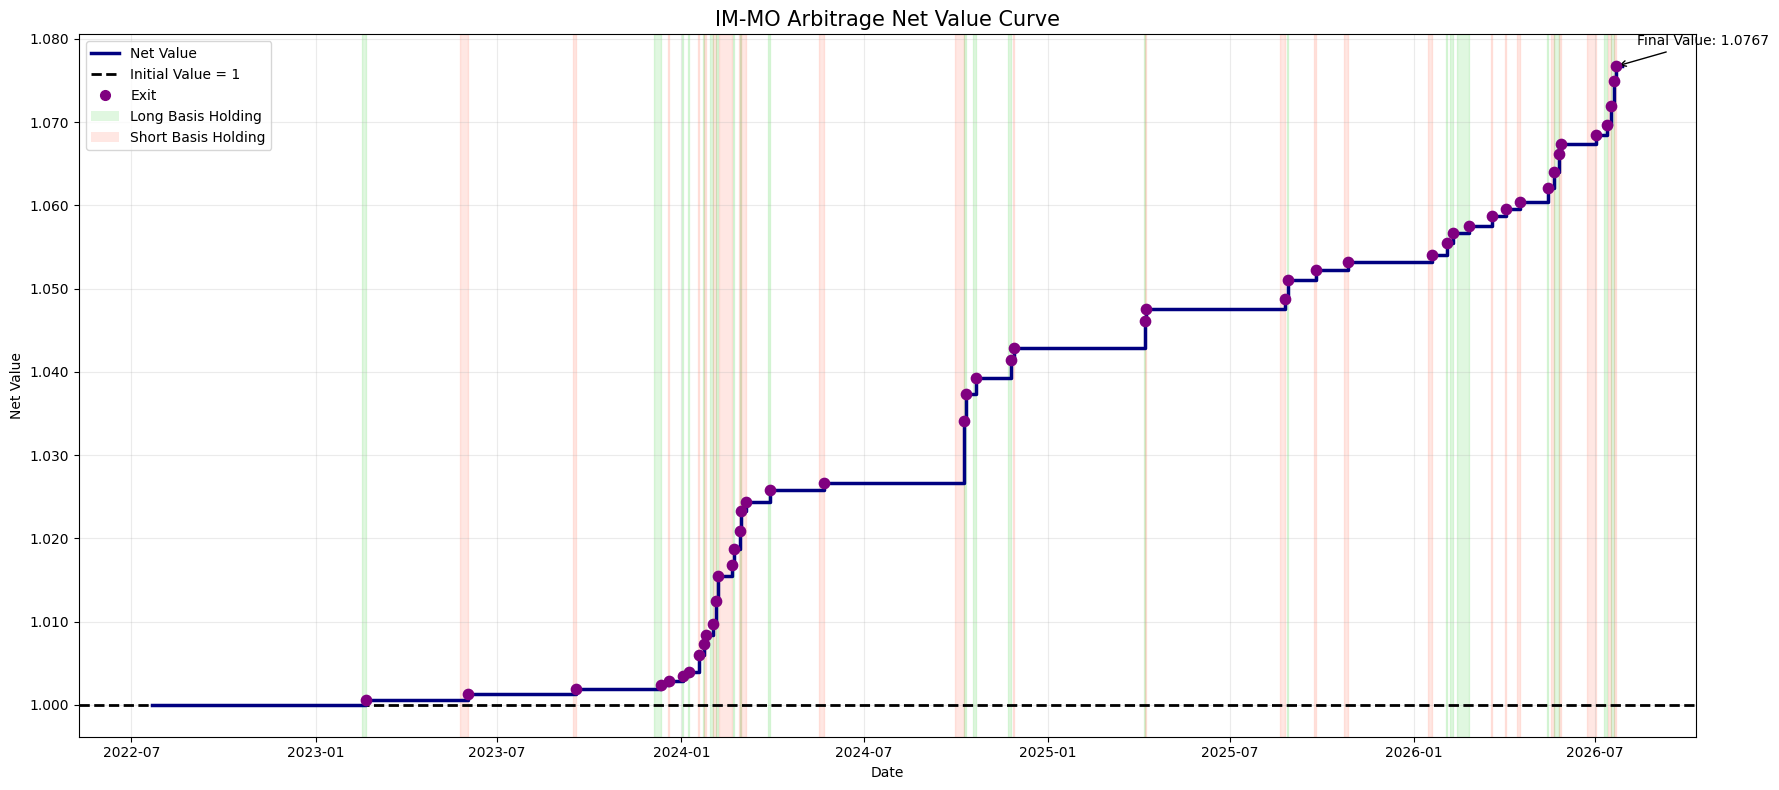

Initial Value: 1.0000
Total Profit: ¥767,200.00
Final Value: 1.0767
Total Return: 7.67%


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

# ==========================
# 参数
# ==========================

initial_capital = 10_000_000
initial_value = 1.0
groups = 1

# ==========================
# 整理交易数据
# ==========================

capital_plot = trade_df.copy()

capital_plot['entry_date'] = pd.to_datetime(
    capital_plot['entry_date']
)

capital_plot['exit_date'] = pd.to_datetime(
    capital_plot['exit_date']
)

capital_plot = (
    capital_plot
    .sort_values('exit_date')
    .reset_index(drop=True)
)

# 实际每笔收益
capital_plot['actual_profit'] = (
    capital_plot['profit'] * groups
)

# 累计收益
capital_plot['cumulative_profit'] = (
    capital_plot['actual_profit'].cumsum()
)

# 净值：初始值为1
capital_plot['net_value'] = (
    initial_value
    + capital_plot['cumulative_profit'] / initial_capital
)

# ==========================
# 构造完整净值曲线
# ==========================

start_date = pd.to_datetime(final_data.index.min())
end_date = pd.to_datetime(final_data.index.max())

net_value_curve = pd.concat(
    [
        pd.DataFrame({
            'date': [start_date],
            'net_value': [initial_value]
        }),

        capital_plot[
            ['exit_date', 'net_value']
        ].rename(
            columns={'exit_date': 'date'}
        ),

        pd.DataFrame({
            'date': [end_date],
            'net_value': [
                capital_plot['net_value'].iloc[-1]
            ]
        })
    ],
    ignore_index=True
)

net_value_curve = (
    net_value_curve
    .sort_values('date')
    .drop_duplicates(
        subset='date',
        keep='last'
    )
)

# ==========================
# 绘图
# ==========================

fig, ax = plt.subplots(figsize=(18, 8))

# 持仓背景
for _, trade in capital_plot.iterrows():

    if trade['direction'] == 'long_basis':
        background_color = 'limegreen'
    else:
        background_color = 'tomato'

    ax.axvspan(
        trade['entry_date'],
        trade['exit_date'],
        color=background_color,
        alpha=0.15,
        zorder=0
    )

# 初始净值线
ax.axhline(
    y=1,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Initial Value = 1'
)

# 净值趋势线
ax.step(
    net_value_curve['date'],
    net_value_curve['net_value'],
    where='post',
    color='navy',
    linewidth=2.5,
    label='Net Value',
    zorder=3
)

# 平仓时净值点
ax.scatter(
    capital_plot['exit_date'],
    capital_plot['net_value'],
    color='purple',
    s=55,
    zorder=4,
    label='Exit'
)

# 最终净值标注
final_net_value = capital_plot['net_value'].iloc[-1]

ax.annotate(
    f'Final Value: {final_net_value:.4f}',
    xy=(
        capital_plot['exit_date'].iloc[-1],
        final_net_value
    ),
    xytext=(15, 15),
    textcoords='offset points',
    arrowprops={
        'arrowstyle': '->',
        'color': 'black'
    }
)

legend_items = [
    plt.Line2D(
        [0], [0],
        color='navy',
        linewidth=2.5,
        label='Net Value'
    ),
    plt.Line2D(
        [0], [0],
        color='black',
        linestyle='--',
        linewidth=2,
        label='Initial Value = 1'
    ),
    plt.Line2D(
        [0], [0],
        marker='o',
        color='purple',
        linestyle='None',
        markersize=7,
        label='Exit'
    ),
    Patch(
        facecolor='limegreen',
        alpha=0.15,
        label='Long Basis Holding'
    ),
    Patch(
        facecolor='tomato',
        alpha=0.15,
        label='Short Basis Holding'
    )
]

ax.legend(
    handles=legend_items,
    loc='best'
)

ax.set_title(
    'IM-MO Arbitrage Net Value Curve',
    fontsize=15
)

ax.set_xlabel('Date')
ax.set_ylabel('Net Value')

ax.yaxis.set_major_formatter(
    FormatStrFormatter('%.3f')
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Initial Value: {initial_value:.4f}")
print(f"Total Profit: ¥{capital_plot['actual_profit'].sum():,.2f}")
print(f"Final Value: {final_net_value:.4f}")
print(
    f"Total Return: "
    f"{(final_net_value / initial_value - 1) * 100:.2f}%"
)

entry_date 按普通日期格式转换。
exit_date 按普通日期格式转换。
final_data 日期范围： 2022-07-22 00:00:00 至 2026-07-28 00:00:00
trade_df 开仓日期范围： 2023-02-16 00:00:00 至 2026-07-20 00:00:00
trade_df 平仓日期范围： 2023-02-20 00:00:00 至 2026-07-22 00:00:00
有效交易笔数： 47


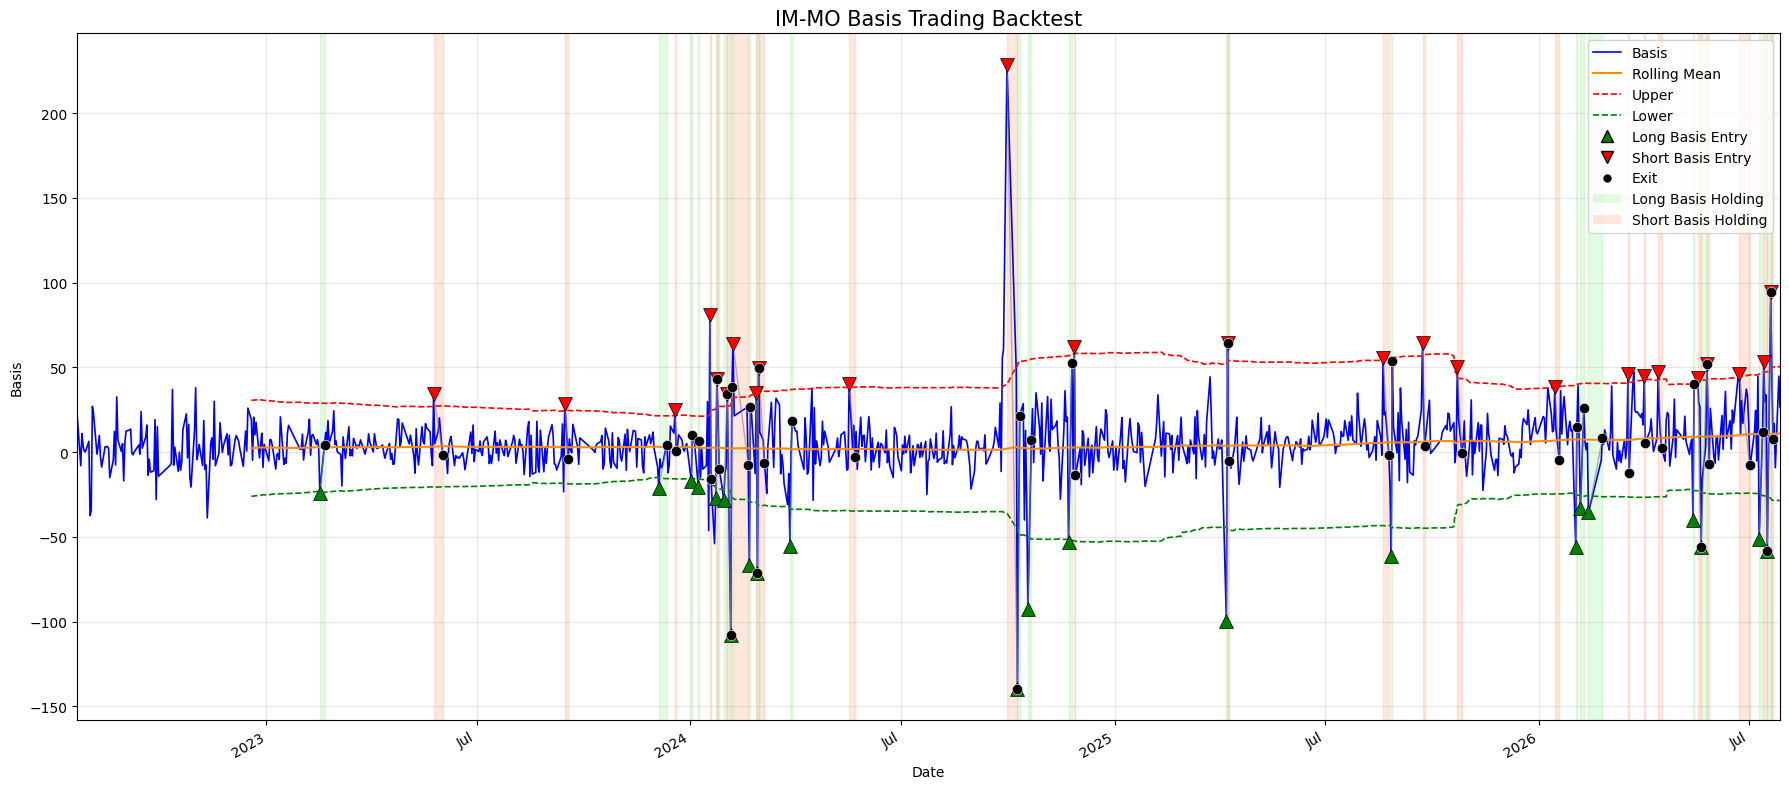

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# 1. 参数
# ============================================================

figsize = (18, 8)

basis_color = 'blue'
rolling_mean_color = 'darkorange'
upper_color = 'red'
lower_color = 'green'

long_background_color = 'lightgreen'
short_background_color = 'lightsalmon'

long_entry_color = 'green'
short_entry_color = 'red'
exit_color = 'black'


# ============================================================
# 2. 检查数据
# ============================================================

if final_data.empty:
    raise ValueError(
        "final_data 为空，无法绘图。"
    )

if trade_df.empty:
    raise ValueError(
        "trade_df 为空，无法绘制交易区间。"
    )


required_final_columns = [
    'basis',
    'rolling_mean',
    'upper',
    'lower'
]

missing_final_columns = [
    col
    for col in required_final_columns
    if col not in final_data.columns
]

if missing_final_columns:
    raise KeyError(
        f"final_data 缺少以下列：{missing_final_columns}"
    )


required_trade_columns = [
    'entry_date',
    'exit_date',
    'entry_basis',
    'exit_basis',
    'direction'
]

missing_trade_columns = [
    col
    for col in required_trade_columns
    if col not in trade_df.columns
]

if missing_trade_columns:
    raise KeyError(
        f"trade_df 缺少以下列：{missing_trade_columns}"
    )


# ============================================================
# 3. 复制数据，避免修改原始 DataFrame
# ============================================================

plot_data = final_data.copy()
plot_trades = trade_df.copy()


# ============================================================
# 4. 处理 final_data 日期
# ============================================================

if isinstance(plot_data.index, pd.DatetimeIndex):

    plot_data.index = pd.to_datetime(
        plot_data.index,
        errors='coerce'
    )

else:

    possible_date_columns = [
        'date',
        'Date',
        'datetime',
        'trade_date',
        '交易日期',
        '日期'
    ]

    date_column = None

    for col in possible_date_columns:
        if col in plot_data.columns:
            date_column = col
            break

    if date_column is None:
        raise ValueError(
            "final_data 的索引不是日期，并且找不到日期列。"
            "请检查 final_data 中是否存在 date、Date、trade_date 或 日期列。"
        )

    plot_data[date_column] = pd.to_datetime(
        plot_data[date_column],
        errors='coerce'
    )

    plot_data = plot_data.set_index(
        date_column
    )


plot_data = plot_data.loc[
    plot_data.index.notna()
].copy()

plot_data = plot_data.sort_index()

plot_data = plot_data[
    ~plot_data.index.duplicated(
        keep='last'
    )
]


# ============================================================
# ============================================================
# 5. 处理 trade_df 日期
# ============================================================

plot_trades = trade_df.copy()

plot_trades['entry_basis'] = pd.to_numeric(
    plot_trades['entry_basis'],
    errors='coerce'
)

plot_trades['exit_basis'] = pd.to_numeric(
    plot_trades['exit_basis'],
    errors='coerce'
)


def convert_trade_date(series, date_index, column_name):
    """
    将交易日期转换成真正的日期。

    支持两种情况：
    1. series 中已经是真实日期，例如 2024-01-05
    2. series 中是 final_data 的行号，例如 0、1、2、3
    """

    series = series.copy()

    # --------------------------------------------------------
    # 判断是否为数字行号
    # --------------------------------------------------------

    numeric_series = pd.to_numeric(
        series,
        errors='coerce'
    )

    numeric_ratio = numeric_series.notna().mean()

    # 大部分值都是数字时，优先判断它是不是行号
    if numeric_ratio >= 0.8:

        valid_numeric = numeric_series.dropna()

        if not valid_numeric.empty:

            minimum_value = valid_numeric.min()
            maximum_value = valid_numeric.max()

            # 数字位于 0 至 len(final_data)-1，说明它是行位置
            if (
                minimum_value >= 0
                and maximum_value < len(date_index)
            ):

                position = numeric_series.round().astype('Int64')

                converted = pd.Series(
                    pd.NaT,
                    index=series.index,
                    dtype='datetime64[ns]'
                )

                valid_position = (
                    position.notna()
                    & (position >= 0)
                    & (position < len(date_index))
                )

                converted.loc[valid_position] = date_index[
                    position.loc[valid_position].astype(int)
                ].to_numpy()

                print(
                    f"{column_name} 按 final_data 行号转换为日期。"
                )

                return converted

    # --------------------------------------------------------
    # 不是行号，则按照正常日期转换
    # --------------------------------------------------------

    converted = pd.to_datetime(
        series,
        errors='coerce'
    )

    print(
        f"{column_name} 按普通日期格式转换。"
    )

    return converted


plot_trades['entry_date'] = convert_trade_date(
    plot_trades['entry_date'],
    plot_data.index,
    'entry_date'
)

plot_trades['exit_date'] = convert_trade_date(
    plot_trades['exit_date'],
    plot_data.index,
    'exit_date'
)


# ============================================================
# 6. 删除转换失败的交易
# ============================================================

before_drop = len(plot_trades)

plot_trades = plot_trades.dropna(
    subset=[
        'entry_date',
        'exit_date',
        'entry_basis',
        'exit_basis',
        'direction'
    ]
).copy()

after_drop = len(plot_trades)

if before_drop != after_drop:
    print(
        f"删除了 {before_drop - after_drop} 条日期或基差无效的交易记录。"
    )


# ============================================================
# 7. 修正开仓、平仓顺序
# ============================================================

wrong_order = (
    plot_trades['exit_date']
    < plot_trades['entry_date']
)

if wrong_order.any():

    print(
        f"发现 {wrong_order.sum()} 条平仓日期早于开仓日期，已删除。"
    )

    plot_trades = plot_trades.loc[
        ~wrong_order
    ].copy()


plot_trades = (
    plot_trades
    .sort_values('entry_date')
    .reset_index(drop=True)
)


# ============================================================
# 8. 检查日期范围
# ============================================================

print("=" * 70)

print(
    "final_data 日期范围：",
    plot_data.index.min(),
    "至",
    plot_data.index.max()
)

print(
    "trade_df 开仓日期范围：",
    plot_trades['entry_date'].min(),
    "至",
    plot_trades['entry_date'].max()
)

print(
    "trade_df 平仓日期范围：",
    plot_trades['exit_date'].min(),
    "至",
    plot_trades['exit_date'].max()
)

print(
    "有效交易笔数：",
    len(plot_trades)
)

print("=" * 70)


# ============================================================
# 8. 创建画布
# ============================================================

fig, ax = plt.subplots(
    figsize=figsize
)


# ============================================================
# 9. 绘制持仓背景
# ============================================================

for _, trade in plot_trades.iterrows():

    entry_date = trade['entry_date']
    exit_date = trade['exit_date']
    direction = trade['direction']

    if direction == 'long_basis':

        background_color = long_background_color

    elif direction == 'short_basis':

        background_color = short_background_color

    else:

        continue

    ax.axvspan(
        entry_date,
        exit_date,
        color=background_color,
        alpha=0.25,
        zorder=0
    )


# ============================================================
# 10. 绘制 Basis
# ============================================================

ax.plot(
    plot_data.index,
    plot_data['basis'],
    color=basis_color,
    linewidth=1.2,
    label='Basis',
    zorder=2
)


# ============================================================
# 11. 绘制 Rolling Mean
# ============================================================

ax.plot(
    plot_data.index,
    plot_data['rolling_mean'],
    color=rolling_mean_color,
    linewidth=1.5,
    label='Rolling Mean',
    zorder=2
)


# ============================================================
# 12. 绘制 Upper
# ============================================================

ax.plot(
    plot_data.index,
    plot_data['upper'],
    linestyle='--',
    color=upper_color,
    linewidth=1.2,
    label='Upper',
    zorder=2
)


# ============================================================
# 13. 绘制 Lower
# ============================================================

ax.plot(
    plot_data.index,
    plot_data['lower'],
    linestyle='--',
    color=lower_color,
    linewidth=1.2,
    label='Lower',
    zorder=2
)


# ============================================================
# 14. 绘制交易点和交易轨迹
# ============================================================

for _, trade in plot_trades.iterrows():

    entry_date = trade['entry_date']
    exit_date = trade['exit_date']

    entry_basis = trade['entry_basis']
    exit_basis = trade['exit_basis']

    direction = trade['direction']


    # --------------------------------------------------------
    # 持仓轨迹
    # --------------------------------------------------------

    ax.plot(
        [entry_date, exit_date],
        [entry_basis, exit_basis],
        color='grey',
        alpha=0.6,
        linewidth=1,
        zorder=3
    )


    # --------------------------------------------------------
    # long basis 开仓
    # --------------------------------------------------------

    if direction == 'long_basis':

        ax.scatter(
            entry_date,
            entry_basis,
            marker='^',
            color=long_entry_color,
            edgecolor='black',
            linewidth=0.5,
            s=100,
            zorder=5
        )


    # --------------------------------------------------------
    # short basis 开仓
    # --------------------------------------------------------

    elif direction == 'short_basis':

        ax.scatter(
            entry_date,
            entry_basis,
            marker='v',
            color=short_entry_color,
            edgecolor='black',
            linewidth=0.5,
            s=100,
            zorder=5
        )


    # --------------------------------------------------------
    # 平仓点
    # --------------------------------------------------------

    ax.scatter(
        exit_date,
        exit_basis,
        marker='o',
        color=exit_color,
        edgecolor='white',
        linewidth=0.4,
        s=55,
        zorder=6
    )


# ============================================================
# 15. 设置横轴日期格式
# ============================================================

date_locator = mdates.AutoDateLocator(
    minticks=6,
    maxticks=12
)

date_formatter = mdates.ConciseDateFormatter(
    date_locator
)

ax.xaxis.set_major_locator(
    date_locator
)

ax.xaxis.set_major_formatter(
    date_formatter
)


# ============================================================
# 16. 设置横轴范围
# ============================================================

ax.set_xlim(
    plot_data.index.min(),
    plot_data.index.max()
)


# ============================================================
# 17. 自定义图例
# ============================================================

legend_elements = [

    Line2D(
        [0],
        [0],
        color=basis_color,
        linewidth=1.2,
        label='Basis'
    ),

    Line2D(
        [0],
        [0],
        color=rolling_mean_color,
        linewidth=1.5,
        label='Rolling Mean'
    ),

    Line2D(
        [0],
        [0],
        color=upper_color,
        linestyle='--',
        linewidth=1.2,
        label='Upper'
    ),

    Line2D(
        [0],
        [0],
        color=lower_color,
        linestyle='--',
        linewidth=1.2,
        label='Lower'
    ),

    Line2D(
        [0],
        [0],
        marker='^',
        linestyle='None',
        markerfacecolor=long_entry_color,
        markeredgecolor='black',
        markersize=9,
        label='Long Basis Entry'
    ),

    Line2D(
        [0],
        [0],
        marker='v',
        linestyle='None',
        markerfacecolor=short_entry_color,
        markeredgecolor='black',
        markersize=9,
        label='Short Basis Entry'
    ),

    Line2D(
        [0],
        [0],
        marker='o',
        linestyle='None',
        markerfacecolor=exit_color,
        markeredgecolor='white',
        markersize=7,
        label='Exit'
    ),

    Patch(
        facecolor=long_background_color,
        alpha=0.25,
        label='Long Basis Holding'
    ),

    Patch(
        facecolor=short_background_color,
        alpha=0.25,
        label='Short Basis Holding'
    )
]


ax.legend(
    handles=legend_elements,
    loc='upper right',
    frameon=True
)


# ============================================================
# 18. 图形格式
# ============================================================

ax.set_title(
    'IM-MO Basis Trading Backtest',
    fontsize=15
)

ax.set_xlabel(
    'Date'
)

ax.set_ylabel(
    'Basis'
)

ax.grid(
    alpha=0.3
)

fig.autofmt_xdate()

plt.tight_layout()

plt.show()

In [7]:
import pandas as pd
import numpy as np


# ============================================================
# 1. 参数
# ============================================================

# 每笔交易做多少组
groups = 1

# 一组套利的仓位
IM_lots_per_group = 1
call_lots_per_group = 2
put_lots_per_group = 2

# 合约乘数
IM_multiplier = 200
MO_multiplier = 100

# MO费用
MO_trade_fee_per_lot = 15.0
MO_exercise_fee_per_lot = 2.0

# IM费用
IM_trade_fee_rate = 0.000023       # 万分之0.23
IM_delivery_fee_rate = 0.0001      # 万分之1

# Market Impact
market_impact_rate = 0.0008        # 0.08%


# ============================================================
# 2. 检查必要列
# ============================================================

required_columns = [
    'entry_date',
    'exit_date',
    'entry_IM',
    'exit_IM',
    'entry_MO',
    'exit_MO',
    'profit',
    'exit_reason'
]

missing_columns = [
    col for col in required_columns
    if col not in trade_df.columns
]

if missing_columns:
    raise KeyError(
        f"trade_df缺少以下必要列：{missing_columns}"
    )


# ============================================================
# 3. 复制数据并清理旧成本列
# ============================================================

trade_df = trade_df.copy()

# 多次运行单元格时，先删除以前生成的成本和收益列
derived_columns = [
    'gross_profit',

    'entry_MO_trade_fee',
    'entry_IM_trade_fee',
    'entry_fixed_cost',

    'exit_MO_trade_fee',
    'exit_IM_trade_fee',
    'MO_exercise_fee',
    'IM_delivery_fee',
    'exit_fixed_cost',

    'entry_IM_notional',
    'entry_MO_notional',
    'exit_IM_notional',
    'exit_MO_notional',
    'entry_notional',
    'exit_notional',

    'entry_market_impact',
    'exit_market_impact',
    'market_impact',

    'fixed_cost',
    'total_cost',
    'net_profit',

    'cumulative_gross_profit',
    'cumulative_fixed_cost',
    'cumulative_market_impact',
    'cumulative_total_cost',
    'cumulative_net_profit',

    'gross_net_value',
    'net_value'
]

trade_df = trade_df.drop(
    columns=derived_columns,
    errors='ignore'
)

# 如果之前concat产生了完全重复的列名，保留第一列
trade_df = trade_df.loc[
    :,
    ~trade_df.columns.duplicated()
].copy()


# ============================================================
# 4. 类型整理
# ============================================================

trade_df['entry_date'] = pd.to_datetime(
    trade_df['entry_date']
)

trade_df['exit_date'] = pd.to_datetime(
    trade_df['exit_date']
)

numeric_columns = [
    'entry_IM',
    'exit_IM',
    'entry_MO',
    'exit_MO',
    'profit'
]

for col in numeric_columns:
    trade_df[col] = pd.to_numeric(
        trade_df[col],
        errors='coerce'
    )

trade_df = (
    trade_df
    .sort_values('exit_date')
    .reset_index(drop=True)
)

if trade_df[numeric_columns].isna().any().any():
    problem_rows = trade_df[
        trade_df[numeric_columns].isna().any(axis=1)
    ]

    raise ValueError(
        "部分价格或收益无法转换为数值，请检查以下记录：\n"
        f"{problem_rows[numeric_columns]}"
    )


# ============================================================
# 5. 每笔交易成本计算函数
# ============================================================

def calculate_trade_cost(row, groups=1):
    """
    按照：
    1手IM + 2手Call + 2手Put
    计算每笔完整套利交易的成本。

    注意：
    当前没有Call、Put各自价格，
    Market Impact暂时使用MO_synthetic名义金额近似。
    """

    entry_IM = abs(float(row['entry_IM']))
    exit_IM = abs(float(row['exit_IM']))

    entry_MO = abs(float(row['entry_MO']))
    exit_MO = abs(float(row['exit_MO']))

    exit_reason = str(row['exit_reason']).lower()

    total_IM_lots = IM_lots_per_group * groups
    total_call_lots = call_lots_per_group * groups
    total_put_lots = put_lots_per_group * groups
    total_MO_option_lots = total_call_lots + total_put_lots

    # --------------------------------------------------------
    # A. 开仓手续费
    # --------------------------------------------------------

    # 2手Call + 2手Put
    entry_MO_trade_fee = (
        total_MO_option_lots
        * MO_trade_fee_per_lot
    )

    # IM成交金额 × 万分之0.23
    entry_IM_trade_fee = (
        entry_IM
        * IM_multiplier
        * total_IM_lots
        * IM_trade_fee_rate
    )

    entry_fixed_cost = (
        entry_MO_trade_fee
        + entry_IM_trade_fee
    )

    # --------------------------------------------------------
    # B. 开仓Market Impact
    # --------------------------------------------------------

    entry_IM_notional = (
        entry_IM
        * IM_multiplier
        * total_IM_lots
    )

    # MO synthetic价格 × 100 × 2组合作近似
    # 不把Call和Put共4张全部乘到合成期货价格上，
    # 因为MO_synthetic本身是一个合成期货价格。
    entry_MO_notional = (
        entry_MO
        * MO_multiplier
        * 2
        * groups
    )

    entry_notional = (
        entry_IM_notional
        + entry_MO_notional
    )

    entry_market_impact = (
        entry_notional
        * market_impact_rate
    )

    # --------------------------------------------------------
    # C. 平仓或到期费用
    # --------------------------------------------------------

    expiry_reasons = {
        'expiry',
        'expiration',
        'delivery'
    }

    is_expiry = exit_reason in expiry_reasons

    if is_expiry:
        # 到期时不计算普通平仓手续费
        exit_MO_trade_fee = 0.0
        exit_IM_trade_fee = 0.0

        # 4张期权的行权手续费
        MO_exercise_fee = (
            total_MO_option_lots
            * MO_exercise_fee_per_lot
        )

        # IM交割手续费
        IM_delivery_fee = (
            exit_IM
            * IM_multiplier
            * total_IM_lots
            * IM_delivery_fee_rate
        )

        exit_fixed_cost = (
            MO_exercise_fee
            + IM_delivery_fee
        )

        # 到期结算不经过盘口，暂不计算退出Market Impact
        exit_IM_notional = 0.0
        exit_MO_notional = 0.0
        exit_notional = 0.0
        exit_market_impact = 0.0

    else:
        # 正常平仓，包括：
        # mean_reversion、roll、contract_change、end_of_backtest等

        exit_MO_trade_fee = (
            total_MO_option_lots
            * MO_trade_fee_per_lot
        )

        exit_IM_trade_fee = (
            exit_IM
            * IM_multiplier
            * total_IM_lots
            * IM_trade_fee_rate
        )

        MO_exercise_fee = 0.0
        IM_delivery_fee = 0.0

        exit_fixed_cost = (
            exit_MO_trade_fee
            + exit_IM_trade_fee
        )

        exit_IM_notional = (
            exit_IM
            * IM_multiplier
            * total_IM_lots
        )

        exit_MO_notional = (
            exit_MO
            * MO_multiplier
            * 2
            * groups
        )

        exit_notional = (
            exit_IM_notional
            + exit_MO_notional
        )

        exit_market_impact = (
            exit_notional
            * market_impact_rate
        )

    # --------------------------------------------------------
    # D. 汇总
    # --------------------------------------------------------

    fixed_cost = (
        entry_fixed_cost
        + exit_fixed_cost
    )

    market_impact = (
        entry_market_impact
        + exit_market_impact
    )

    total_cost = (
        fixed_cost
        + market_impact
    )

    return pd.Series({
        'entry_MO_trade_fee': entry_MO_trade_fee,
        'entry_IM_trade_fee': entry_IM_trade_fee,
        'entry_fixed_cost': entry_fixed_cost,

        'exit_MO_trade_fee': exit_MO_trade_fee,
        'exit_IM_trade_fee': exit_IM_trade_fee,
        'MO_exercise_fee': MO_exercise_fee,
        'IM_delivery_fee': IM_delivery_fee,
        'exit_fixed_cost': exit_fixed_cost,

        'entry_IM_notional': entry_IM_notional,
        'entry_MO_notional': entry_MO_notional,
        'entry_notional': entry_notional,

        'exit_IM_notional': exit_IM_notional,
        'exit_MO_notional': exit_MO_notional,
        'exit_notional': exit_notional,

        'entry_market_impact': entry_market_impact,
        'exit_market_impact': exit_market_impact,
        'market_impact': market_impact,

        'fixed_cost': fixed_cost,
        'total_cost': total_cost
    })


# ============================================================
# 6. 应用成本函数
# ============================================================

cost_result = trade_df.apply(
    calculate_trade_cost,
    axis=1,
    groups=groups
)

# 不使用concat重复拼接，逐列覆盖，避免重复列名
for col in cost_result.columns:
    trade_df[col] = cost_result[col].to_numpy()


# ============================================================
# 7. 毛收益和净收益
# ============================================================

# 假设原profit为单组毛收益
trade_df['gross_profit'] = (
    trade_df['profit']
    * groups
)

trade_df['net_profit'] = (
    trade_df['gross_profit']
    - trade_df['total_cost']
)


# ============================================================
# 8. 累计收益
# ============================================================

trade_df['cumulative_gross_profit'] = (
    trade_df['gross_profit'].cumsum()
)

trade_df['cumulative_fixed_cost'] = (
    trade_df['fixed_cost'].cumsum()
)

trade_df['cumulative_market_impact'] = (
    trade_df['market_impact'].cumsum()
)

trade_df['cumulative_total_cost'] = (
    trade_df['total_cost'].cumsum()
)

trade_df['cumulative_net_profit'] = (
    trade_df['net_profit'].cumsum()
)


# ============================================================
# 9. 净值
# ============================================================

initial_capital = 10_000_000

trade_df['gross_net_value'] = (
    1
    + trade_df['cumulative_gross_profit']
    / initial_capital
)

trade_df['net_value'] = (
    1
    + trade_df['cumulative_net_profit']
    / initial_capital
)


# ============================================================
# 10. 汇总统计
# ============================================================

total_gross_profit = trade_df['gross_profit'].sum()
total_fixed_cost = trade_df['fixed_cost'].sum()
total_market_impact = trade_df['market_impact'].sum()
total_cost = trade_df['total_cost'].sum()
total_net_profit = trade_df['net_profit'].sum()

gross_return = (
    total_gross_profit
    / initial_capital
)

net_return = (
    total_net_profit
    / initial_capital
)

gross_win_rate = (
    trade_df['gross_profit'] > 0
).mean()

net_win_rate = (
    trade_df['net_profit'] > 0
).mean()

final_gross_net_value = (
    trade_df['gross_net_value'].iloc[-1]
    if not trade_df.empty
    else 1.0
)

final_net_value = (
    trade_df['net_value'].iloc[-1]
    if not trade_df.empty
    else 1.0
)


# ============================================================
# 11. 输出结果
# ============================================================

print("=" * 72)
print("IM当月 + MO合成期货统计套利成本核算")
print("=" * 72)

print(f"交易笔数：{len(trade_df)}")
print(f"每笔交易组数：{groups}")

print(
    f"套利组合："
    f"{IM_lots_per_group}手IM + "
    f"{call_lots_per_group}手Call + "
    f"{put_lots_per_group}手Put"
)

print("-" * 72)

print(f"MO交易手续费：{MO_trade_fee_per_lot:.2f} 元/手")
print(f"MO行权手续费：{MO_exercise_fee_per_lot:.2f} 元/手")
print(f"IM交易手续费率：{IM_trade_fee_rate * 10000:.2f} 万分点")
print(f"IM交割手续费率：{IM_delivery_fee_rate * 10000:.2f} 万分点")
print(f"Market Impact：{market_impact_rate * 100:.2f}%")

print("-" * 72)

print(f"总毛收益：{total_gross_profit:,.2f} 元")
print(f"总固定成本：{total_fixed_cost:,.2f} 元")
print(f"总Market Impact：{total_market_impact:,.2f} 元")
print(f"总交易成本：{total_cost:,.2f} 元")
print(f"总净收益：{total_net_profit:,.2f} 元")

print("-" * 72)

print(f"不扣成本区间收益率：{gross_return * 100:.4f}%")
print(f"扣除全部成本收益率：{net_return * 100:.4f}%")

print(f"毛收益胜率：{gross_win_rate * 100:.2f}%")
print(f"净收益胜率：{net_win_rate * 100:.2f}%")

print(f"最终毛净值：{final_gross_net_value:.6f}")
print(f"最终净值：{final_net_value:.6f}")

print("=" * 72)

print(
    "重复列：",
    trade_df.columns[
        trade_df.columns.duplicated()
    ].tolist()
)


# ============================================================
# 12. 查看每笔交易明细
# ============================================================

display_columns = [
    'entry_date',
    'exit_date',
    'direction',
    'exit_reason',

    'gross_profit',

    'entry_MO_trade_fee',
    'entry_IM_trade_fee',
    'exit_MO_trade_fee',
    'exit_IM_trade_fee',
    'MO_exercise_fee',
    'IM_delivery_fee',

    'fixed_cost',
    'entry_market_impact',
    'exit_market_impact',
    'market_impact',
    'total_cost',

    'net_profit',
    'net_value'
]

trade_df[display_columns].head()

IM当月 + MO合成期货统计套利成本核算
交易笔数：47
每笔交易组数：1
套利组合：1手IM + 2手Call + 2手Put
------------------------------------------------------------------------
MO交易手续费：15.00 元/手
MO行权手续费：2.00 元/手
IM交易手续费率：0.23 万分点
IM交割手续费率：1.00 万分点
Market Impact：0.08%
------------------------------------------------------------------------
总毛收益：767,200.00 元
总固定成本：8,443.91 元
总Market Impact：195,115.20 元
总交易成本：203,559.11 元
总净收益：563,640.89 元
------------------------------------------------------------------------
不扣成本区间收益率：7.6720%
扣除全部成本收益率：5.6364%
毛收益胜率：100.00%
净收益胜率：100.00%
最终毛净值：1.076720
最终净值：1.056364
重复列： []


,entry_date,exit_date,direction,exit_reason,gross_profit,entry_MO_trade_fee,entry_IM_trade_fee,exit_MO_trade_fee,exit_IM_trade_fee,MO_exercise_fee,IM_delivery_fee,fixed_cost,entry_market_impact,exit_market_impact,market_impact,total_cost,net_profit,net_value
0,2023-02-16,2023-02-20,long_basis,mean_reversion,5640.0,60.0,31.89364,60.0,31.80624,0.0,0.0,183.69988,2214.848,2213.280,4428.128,4611.82788,1028.17212,1.000103
1,2023-05-25,2023-06-02,short_basis,mean_reversion,7080.0,60.0,29.67828,60.0,30.43728,0.0,0.0,180.11556,2070.016,2117.152,4187.168,4367.28356,2712.71644,1.000374
2,2023-09-15,2023-09-18,short_basis,mean_reversion,6520.0,60.0,27.80516,60.0,28.01032,0.0,0.0,175.81548,1938.816,1947.872,3886.688,4062.50348,2457.49652,1.000620
3,2023-12-05,2023-12-12,long_basis,mean_reversion,5040.0,60.0,27.47948,60.0,27.95880,0.0,0.0,175.43828,1908.224,1945.600,3853.824,4029.26228,1010.73772,1.000721
4,2023-12-19,2023-12-20,short_basis,mean_reversion,4840.0,60.0,26.78672,60.0,26.45736,0.0,0.0,173.24408,1867.424,1840.640,3708.064,3881.30808,958.69192,1.000817


In [8]:
import sys
from pathlib import Path

project_root = Path.cwd()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.attribution import (
    run_basis_attribution,
    export_attribution_markdown,
)


In [9]:
prepared_data, abnormal_events, attribution_results = (
    run_basis_attribution(
        final_data=final_data.reset_index(),
        basis_definition="MO_MINUS_IM",
        z_threshold=2.0,
        change_z_threshold=2.0,
        top_n=30,
        min_gap_days=3,
        near_expiry_days=5,
        output_dir="outputs",
    )
)

IM-MO Basis Attribution Engine
Basis定义最大验算误差： 7.105427357601002e-15
异常事件数量：30
归因结果已保存至：
outputs/basis_attribution_results.csv


In [10]:
attribution_results[
    [
        'date',
        'basis',
        'z_score',
        'basis_change',
        'primary_reason',
        'primary_score',
        'confidence',
        'dominant_leg',
        'secondary_reasons'
    ]
]

,date,basis,z_score,basis_change,primary_reason,primary_score,confidence,dominant_leg,secondary_reasons
0,2023-05-25,34.0,3.519927,42.0,Basis Jump,80.000000,Medium,IM,IM Price Contribution
1,2023-08-16,-14.4,-2.165262,-32.4,Basis Jump,79.463323,Medium,Mixed,Mixed Price Contribution
2,2023-09-15,28.4,2.598200,51.8,Contract Roll,100.000000,High,MO Synthetic,Basis Jump | MO Synthetic Price Contribution
3,2023-12-05,-21.2,-2.648995,-12.4,Mixed Price Contribution,45.000000,Low,Mixed,
4,2024-01-18,81.0,6.895051,127.2,Contract Roll,100.000000,High,IM,Basis Jump | IM Price Contribution
5,2024-01-22,-54.0,-4.074963,-38.0,Mixed Price Contribution,45.000000,Low,Mixed,
6,2024-02-05,-107.8,-6.639918,-142.2,Basis Jump,80.000000,Medium,Mixed,Mixed Price Contribution
7,2024-02-21,-66.6,-3.256534,-59.2,IM Price Contribution,65.000000,Medium,IM,
8,2024-02-29,49.6,2.013109,121.0,Basis Jump,80.000000,Medium,MO Synthetic,MO Synthetic Price Contribution
9,2024-09-26,55.8,5.355327,67.2,Basis Jump,80.000000,Medium,Mixed,Mixed Price Contribution


In [11]:
attribution_results[
    'primary_reason'
].value_counts()

primary_reason
Basis Jump                  22
Mixed Price Contribution     5
Contract Roll                2
IM Price Contribution        1
Name: count, dtype: int64

In [12]:
import numpy as np
import pandas as pd


def enrich_attribution_results(
    attribution_results: pd.DataFrame,
) -> pd.DataFrame:
    """
    在V1归因结果上增加：
    1. IM和MO的贡献占比
    2. 贡献方向
    3. 自动文字解释
    4. 结构性证据
    """

    result = attribution_results.copy()

    # ========================================================
    # 1. 贡献绝对值
    # ========================================================

    result["IM_abs_contribution"] = (
        result["IM_contribution"].abs()
    )

    result["MO_abs_contribution"] = (
        result["MO_contribution"].abs()
    )

    result["total_abs_contribution"] = (
        result["IM_abs_contribution"]
        + result["MO_abs_contribution"]
    )

    # ========================================================
    # 2. 贡献比例
    #
    # 使用绝对值计算“谁主导了变化”
    # ========================================================

    result["IM_contribution_share"] = np.where(
        result["total_abs_contribution"] > 0,
        (
            result["IM_abs_contribution"]
            / result["total_abs_contribution"]
        ),
        np.nan,
    )

    result["MO_contribution_share"] = np.where(
        result["total_abs_contribution"] > 0,
        (
            result["MO_abs_contribution"]
            / result["total_abs_contribution"]
        ),
        np.nan,
    )

    # ========================================================
    # 3. 贡献百分比
    # ========================================================

    result["IM_contribution_pct"] = (
        result["IM_contribution_share"] * 100
    )

    result["MO_contribution_pct"] = (
        result["MO_contribution_share"] * 100
    )

    # ========================================================
    # 4. 自动生成结构性证据
    # ========================================================

    def build_evidence(row):

        evidence = []

        if row["primary_reason"] == "Contract Roll":
            evidence.append("Contract roll detected")

        secondary = str(
            row.get("secondary_reasons", "")
        )

        if "Near Expiry" in secondary:
            evidence.append("Near-expiry condition detected")

        if "ATM Strike Change" in secondary:
            evidence.append("Selected MO strike changed")

        if "Basis Jump" in secondary:
            evidence.append("Large daily basis jump detected")

        if not evidence:
            evidence.append(
                "No strong contract-related evidence detected"
            )

        return " | ".join(evidence)

    result["structural_evidence"] = result.apply(
        build_evidence,
        axis=1,
    )

    # ========================================================
    # 5. 自动生成研究解释
    # ========================================================

    def build_explanation(row):

        basis_change = row["basis_change"]
        im_contribution = row["IM_contribution"]
        mo_contribution = row["MO_contribution"]

        im_pct = row["IM_contribution_pct"]
        mo_pct = row["MO_contribution_pct"]

        if pd.isna(basis_change):
            return "Insufficient data to explain the basis movement."

        # Basis变化方向
        if basis_change > 0:
            direction_text = (
                f"The IM-MO basis increased by "
                f"{basis_change:.2f} points."
            )
        elif basis_change < 0:
            direction_text = (
                f"The IM-MO basis decreased by "
                f"{abs(basis_change):.2f} points."
            )
        else:
            direction_text = (
                "The IM-MO basis was unchanged."
            )

        # 主导腿
        if (
            pd.notna(im_pct)
            and im_pct >= 65
        ):
            driver_text = (
                f"The movement was primarily driven by IM futures. "
                f"The IM leg contributed "
                f"{im_contribution:+.2f} points, accounting for "
                f"{im_pct:.1f}% of the total absolute price contribution."
            )

        elif (
            pd.notna(mo_pct)
            and mo_pct >= 65
        ):
            driver_text = (
                f"The movement was primarily driven by the MO synthetic "
                f"futures leg. The MO synthetic leg contributed "
                f"{mo_contribution:+.2f} points, accounting for "
                f"{mo_pct:.1f}% of the total absolute price contribution."
            )

        else:
            driver_text = (
                f"Both legs contributed materially to the movement. "
                f"IM contributed {im_contribution:+.2f} points "
                f"and MO synthetic contributed "
                f"{mo_contribution:+.2f} points."
            )

        # 结构原因
        reason = row["primary_reason"]

        if reason == "Contract Roll":
            reason_text = (
                "A contract roll occurred on the same date, so part of "
                "the observed movement may reflect pricing differences "
                "between the old and new contracts rather than a pure "
                "market mispricing."
            )

        elif reason == "Near Expiry":
            reason_text = (
                "The contracts were close to expiry, when convergence, "
                "settlement and liquidity effects may become more important."
            )

        elif reason == "ATM Strike Change":
            reason_text = (
                "The selected option strike changed, which may introduce "
                "a discontinuity into the synthetic futures series."
            )

        elif reason == "Basis Jump":
            reason_text = (
                "No higher-scoring mechanical cause was identified, but "
                "the daily basis movement was statistically unusual."
            )

        else:
            reason_text = (
                "No dominant contract-related cause was identified. "
                "Additional volatility, liquidity or market-event data "
                "may be required."
            )

        return (
            direction_text
            + " "
            + driver_text
            + " "
            + reason_text
        )

    result["research_explanation"] = result.apply(
        build_explanation,
        axis=1,
    )

    return result


attribution_v2 = enrich_attribution_results(
    attribution_results
)

In [13]:
attribution_v2[
    [
        "date",
        "basis",
        "basis_change",
        "IM_contribution",
        "MO_contribution",
        "IM_contribution_pct",
        "MO_contribution_pct",
        "primary_reason",
        "confidence",
        "structural_evidence",
        "research_explanation",
    ]
].head(20)

,date,basis,basis_change,IM_contribution,MO_contribution,IM_contribution_pct,MO_contribution_pct,primary_reason,confidence,structural_evidence,research_explanation
0,2023-05-25,34.0,42.0,64.0,-22.0,74.418605,25.581395,Basis Jump,Medium,No strong contract-related evidence detected,The IM-MO basis increased by 42.00 points. The...
1,2023-08-16,-14.4,-32.4,50.6,-83.0,37.874251,62.125749,Basis Jump,Medium,No strong contract-related evidence detected,The IM-MO basis decreased by 32.40 points. Bot...
2,2023-09-15,28.4,51.8,15.2,36.6,29.343629,70.656371,Contract Roll,High,Contract roll detected | Large daily basis jum...,The IM-MO basis increased by 51.80 points. The...
3,2023-12-05,-21.2,-12.4,95.2,-107.6,46.942801,53.057199,Mixed Price Contribution,Low,No strong contract-related evidence detected,The IM-MO basis decreased by 12.40 points. Bot...
4,2024-01-18,81.0,127.2,201.8,-74.6,73.010130,26.989870,Contract Roll,High,Contract roll detected | Large daily basis jum...,The IM-MO basis increased by 127.20 points. Th...
5,2024-01-22,-54.0,-38.0,361.6,-399.6,47.503941,52.496059,Mixed Price Contribution,Low,No strong contract-related evidence detected,The IM-MO basis decreased by 38.00 points. Bot...
6,2024-02-05,-107.8,-142.2,202.8,-345.0,37.020811,62.979189,Basis Jump,Medium,No strong contract-related evidence detected,The IM-MO basis decreased by 142.20 points. Bo...
7,2024-02-21,-66.6,-59.2,-76.8,17.6,81.355932,18.644068,IM Price Contribution,Medium,No strong contract-related evidence detected,The IM-MO basis decreased by 59.20 points. The...
8,2024-02-29,49.6,121.0,-98.0,219.0,30.914826,69.085174,Basis Jump,Medium,No strong contract-related evidence detected,The IM-MO basis increased by 121.00 points. Th...
9,2024-09-26,55.8,67.2,-184.6,251.8,42.300642,57.699358,Basis Jump,Medium,No strong contract-related evidence detected,The IM-MO basis increased by 67.20 points. Bot...


In [14]:
reason_summary = (
    attribution_v2["primary_reason"]
    .value_counts()
    .rename_axis("reason")
    .reset_index(name="event_count")
)

reason_summary["percentage"] = (
    reason_summary["event_count"]
    / reason_summary["event_count"].sum()
    * 100
)

reason_summary

,reason,event_count,percentage
0,Basis Jump,22,73.333333
1,Mixed Price Contribution,5,16.666667
2,Contract Roll,2,6.666667
3,IM Price Contribution,1,3.333333


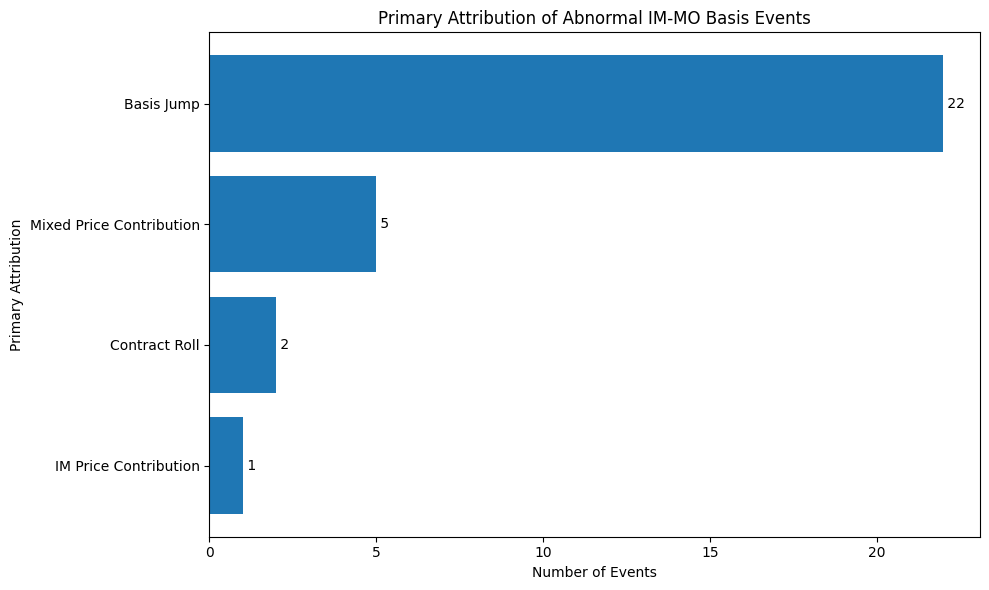

In [15]:
import matplotlib.pyplot as plt


plot_data = reason_summary.sort_values(
    "event_count",
    ascending=True,
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["reason"],
    plot_data["event_count"],
)

plt.title(
    "Primary Attribution of Abnormal IM-MO Basis Events"
)

plt.xlabel("Number of Events")
plt.ylabel("Primary Attribution")

for index, value in enumerate(
    plot_data["event_count"]
):
    plt.text(
        value,
        index,
        f" {value}",
        va="center",
    )

plt.tight_layout()

plt.savefig(
    "IM_MO_Basis_Attribution_Summary.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [16]:
largest_events = (
    attribution_v2
    .assign(
        abs_z_score=lambda x: x["z_score"].abs()
    )
    .sort_values(
        "abs_z_score",
        ascending=False,
    )
    .head(5)
)

In [17]:
#查看单个异常事件的完整解释
import textwrap

for _, row in largest_events.iterrows():

    print("=" * 80)
    print(
        "Date:",
        pd.Timestamp(row["date"]).strftime("%Y-%m-%d")
    )
    print("Basis:", round(row["basis"], 2))
    print("Z-score:", round(row["z_score"], 2))
    print("Basis change:", round(row["basis_change"], 2))
    print("Primary reason:", row["primary_reason"])
    print("Confidence:", row["confidence"])
    print("Evidence:", row["structural_evidence"])
    print()

    print(
        textwrap.fill(
            row["research_explanation"],
            width=90
        )
    )

    print()

Date: 2024-09-30
Basis: 228.6
Z-score: 17.65
Basis change: 168.0
Primary reason: Basis Jump
Confidence: Medium
Evidence: No strong contract-related evidence detected

The IM-MO basis increased by 168.00 points. Both legs contributed materially to the
movement. IM contributed -516.20 points and MO synthetic contributed +684.20 points. No
higher-scoring mechanical cause was identified, but the daily basis movement was
statistically unusual.

Date: 2024-01-18
Basis: 81.0
Z-score: 6.9
Basis change: 127.2
Primary reason: Contract Roll
Confidence: High
Evidence: Contract roll detected | Large daily basis jump detected

The IM-MO basis increased by 127.20 points. The movement was primarily driven by IM
futures. The IM leg contributed +201.80 points, accounting for 73.0% of the total absolute
price contribution. A contract roll occurred on the same date, so part of the observed
movement may reflect pricing differences between the old and new contracts rather than a
pure market mispricing.

Dat

In [18]:
attribution_v2["contribution_error"] = (
    attribution_v2["basis_change"]
    - (
        attribution_v2["IM_contribution"]
        + attribution_v2["MO_contribution"]
    )
)

print(
    "最大贡献分解误差：",
    attribution_v2[
        "contribution_error"
    ].abs().max()
)

最大贡献分解误差： 3.552713678800501e-15


In [19]:
from src.event_calendar import (
    run_event_calendar_matching,
)

In [20]:
attribution_with_events = (
    run_event_calendar_matching(
        attribution_results=attribution_v2,
        calendar_path="data/event_calendar.csv",
        window_days=2,
        output_path=(
            "outputs/"
            "attribution_with_events.csv"
        ),
    )
)

Event Calendar Matching
异常事件数量： 30
成功匹配数量： 5
输出文件： outputs/attribution_with_events.csv


In [21]:
attribution_with_events[
    [
        "date",
        "primary_reason",
        "related_event_found",
        "related_event_name",
        "related_event_importance",
        "event_day_distance",
    ]
]

,date,primary_reason,related_event_found,related_event_name,related_event_importance,event_day_distance
0,2023-05-25,Basis Jump,False,,,<NA>
1,2023-08-16,Basis Jump,False,,,<NA>
2,2023-09-15,Contract Roll,False,,,<NA>
3,2023-12-05,Mixed Price Contribution,False,,,<NA>
4,2024-01-18,Contract Roll,True,Monthly Contract Roll,High,0
5,2024-01-22,Mixed Price Contribution,False,,,<NA>
6,2024-02-05,Basis Jump,True,Small-Cap Market Stress,High,0
7,2024-02-21,IM Price Contribution,False,,,<NA>
8,2024-02-29,Basis Jump,False,,,<NA>
9,2024-09-26,Basis Jump,True,Policy Stimulus Announcement,High,-2


In [22]:
matched_events = attribution_with_events.loc[
    attribution_with_events["related_event_found"]
].copy()

matched_events[
    [
        "date",
        "basis",
        "z_score",
        "primary_reason",
        "related_event_date",
        "related_event_type",
        "related_event_name",
        "related_event_importance",
        "event_day_distance",
    ]
]

,date,basis,z_score,primary_reason,related_event_date,related_event_type,related_event_name,related_event_importance,event_day_distance
4,2024-01-18,81.0,6.895051,Contract Roll,2024-01-18,Contract,Monthly Contract Roll,High,0
6,2024-02-05,-107.8,-6.639918,Basis Jump,2024-02-05,Market,Small-Cap Market Stress,High,0
9,2024-09-26,55.8,5.355327,Basis Jump,2024-09-24,Policy,Policy Stimulus Announcement,High,-2
10,2024-09-30,228.6,17.654669,Basis Jump,2024-09-30,Calendar,Quarter-End Rebalancing,Medium,0
11,2024-10-08,47.2,1.708916,Basis Jump,2024-10-08,Holiday,First Trading Day After National Day Holiday,Medium,0


In [23]:
import textwrap

for _, row in matched_events.iterrows():

    print("=" * 90)

    print(
        "Abnormal date:",
        pd.Timestamp(row["date"]).strftime("%Y-%m-%d")
    )

    print(
        "Related event:",
        row["related_event_name"]
    )

    print(
        "Event date:",
        pd.Timestamp(
            row["related_event_date"]
        ).strftime("%Y-%m-%d")
    )

    print(
        "Distance:",
        row["event_day_distance"],
        "day(s)"
    )

    print()

    print(
        textwrap.fill(
            str(row["event_context_explanation"]),
            width=90,
        )
    )

    print()

Abnormal date: 2024-01-18
Related event: Monthly Contract Roll
Event date: 2024-01-18
Distance: 0 day(s)

The IM-MO basis increased by 127.20 points. The movement was primarily driven by IM
futures. The IM leg contributed +201.80 points, accounting for 73.0% of the total absolute
price contribution. A contract roll occurred on the same date, so part of the observed
movement may reflect pricing differences between the old and new contracts rather than a
pure market mispricing. The event calendar identified 'Monthly Contract Roll' (Contract,
High) on 2024-01-18, on the same date. This is contextual evidence only and does not
establish causality.

Abnormal date: 2024-02-05
Related event: Small-Cap Market Stress
Event date: 2024-02-05
Distance: 0 day(s)

The IM-MO basis decreased by 142.20 points. Both legs contributed materially to the
movement. IM contributed +202.80 points and MO synthetic contributed -345.00 points. No
higher-scoring mechanical cause was identified, but the daily basis

In [24]:
from src.report_generator import generate_research_report

In [26]:
import inspect

print(inspect.signature(generate_research_report))

(attribution: 'pd.DataFrame', output_path: 'str | Path', language: 'str' = 'EN', project_title: 'str | None' = None, top_events: 'int | None' = 10, figure_paths: 'dict[str, str | Path] | None' = None, include_all_events: 'bool' = False) -> 'Path'


In [28]:
import importlib
import src.report_generator

importlib.reload(src.report_generator)

from src.report_generator import (
    generate_bilingual_reports,
)

In [29]:
english_report, chinese_report = generate_bilingual_reports(
    attribution=attribution_with_events,
    english_output_path="outputs/IM_MO_Research_Report.md",
    chinese_output_path="outputs/IM_MO_研究报告.md",
    top_events=10,
    include_all_events=False,
)

print("英文报告：", english_report)
print("中文报告：", chinese_report)

IM-MO English Research Report Generator
Total abnormal events: 30
Detailed events: 10
Inserted figures: 0
Output file: outputs/IM_MO_Research_Report.md
IM-MO 中文研究报告生成器
全部异常事件数量： 30
报告详情事件数量： 10
成功插入图片数量： 0
输出文件： outputs/IM_MO_研究报告.md
中英文报告均已生成
English: outputs/IM_MO_Research_Report.md
中文： outputs/IM_MO_研究报告.md
英文报告： outputs/IM_MO_Research_Report.md
中文报告： outputs/IM_MO_研究报告.md


In [30]:
report = generate_research_report(
    attribution_with_events
)

TypeError: generate_research_report() missing 1 required positional argument: 'output_path'

In [31]:
from src.report_generator import (
    generate_research_report,
)

In [32]:
import importlib
import src.report_generator

importlib.reload(
    src.report_generator
)

from src.report_generator import (
    generate_research_report,
)

In [33]:
report_path = generate_research_report(
    attribution=attribution_with_events,
    output_path=(
        "outputs/"
        "IM_MO_Research_Report.md"
    ),
    project_title=(
        "IM-MO Synthetic Futures "
        "Basis Attribution Report"
    ),
    top_events=10,
)

print(report_path)

IM-MO English Research Report Generator
Total abnormal events: 30
Detailed events: 10
Inserted figures: 0
Output file: outputs/IM_MO_Research_Report.md
outputs/IM_MO_Research_Report.md


In [34]:
import importlib
import src.report_generator

importlib.reload(
    src.report_generator
)

from src.report_generator import (
    generate_bilingual_reports,
)

english_report, chinese_report = (
    generate_bilingual_reports(
        attribution=attribution_with_events,
        english_output_path=(
            "outputs/"
            "IM_MO_Research_Report.md"
        ),
        chinese_output_path=(
            "outputs/"
            "IM_MO_研究报告.md"
        ),
        top_events=10,
        include_all_events=False,
    )
)

print("英文报告：", english_report)
print("中文报告：", chinese_report)

IM-MO English Research Report Generator
Total abnormal events: 30
Detailed events: 10
Inserted figures: 0
Output file: outputs/IM_MO_Research_Report.md
IM-MO 中文研究报告生成器
全部异常事件数量： 30
报告详情事件数量： 10
成功插入图片数量： 0
输出文件： outputs/IM_MO_研究报告.md
中英文报告均已生成
English: outputs/IM_MO_Research_Report.md
中文： outputs/IM_MO_研究报告.md
英文报告： outputs/IM_MO_Research_Report.md
中文报告： outputs/IM_MO_研究报告.md


In [35]:
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)

final_data.reset_index().to_csv(
    "outputs/final_data.csv",
    index=False,
    encoding="utf-8-sig",
)

attribution_results.to_csv(
    "outputs/attribution_results.csv",
    index=False,
    encoding="utf-8-sig",
)

attribution_with_events.to_csv(
    "outputs/attribution_with_events.csv",
    index=False,
    encoding="utf-8-sig",
)

print("关键数据已保存。")

关键数据已保存。


In [ ]:
import importlib
import ipywidgets as widgets
from IPython.display import display, clear_output

import src.attribution
import src.event_calendar
import src.report_generator

importlib.reload(src.attribution)
importlib.reload(src.event_calendar)
importlib.reload(src.report_generator)

from src.attribution import run_basis_attribution
from src.event_calendar import run_event_calendar_matching
from src.report_generator import generate_bilingual_reports


output = widgets.Output()

run_button = widgets.Button(
    description="一键生成分析报告",
    button_style="success",
    icon="play",
)


def run_full_pipeline(button):

    with output:
        clear_output()

        print("开始运行 IM-MO 自动异常分析流程...\n")

        # 1. 异常检测与归因
        prepared_data, abnormal_events, attribution_results = (
            run_basis_attribution(
                final_data=final_data.reset_index(),
                basis_definition="MO_MINUS_IM",
                z_threshold=2.0,
                change_z_threshold=2.0,
                top_n=30,
                min_gap_days=3,
                near_expiry_days=5,
                output_dir="outputs",
            )
        )

        print("\n异常归因完成。\n")

        # 2. 事件日历匹配
        attribution_with_events = (
            run_event_calendar_matching(
                attribution_results=attribution_results,
                calendar_path="data/event_calendar.csv",
                window_days=2,
                output_path=(
                    "outputs/"
                    "attribution_with_events.csv"
                ),
            )
        )

        print("\n事件匹配完成。\n")

        # 3. 生成中英文报告
        english_report, chinese_report = (
            generate_bilingual_reports(
                attribution=attribution_with_events,
                english_output_path=(
                    "outputs/"
                    "IM_MO_Research_Report.md"
                ),
                chinese_output_path=(
                    "outputs/"
                    "IM_MO_研究报告.md"
                ),
                top_events=10,
                include_all_events=False,
            )
        )

        print("\n全部完成。")
        print("英文报告：", english_report)
        print("中文报告：", chinese_report)


run_button.on_click(run_full_pipeline)

display(run_button, output)

Button(button_style='success', description='一键生成分析报告', icon='play', style=ButtonStyle())

Output()